In [1]:
#===============================
# ANALYSE : Mouad AOUS | Ingénieur Qualité de l'Air
# Dataset : Climat Cha,ge - Earth Surface Temprature
#================================

In [2]:
from zipfile import ZipFile
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from matplotlib.colors import Normalize
from matplotlib.cm import RdYlBu_r
import warnings
import scipy.stats as stats
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import r2_score, mean_absolute_error
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.model_selection import TimeSeriesSplit
warnings.filterwarnings("ignore")
import matplotlib.cm as cm


In [3]:
if os.path.exists('../Kaggle/input/'):
    BASE_PATH = '../kaggle/input/'
    print("Environnment Kaggle détécté")
else:
    BASE_PATH = '../data'
    print("Envirennment local détecté")
print(f"Chemin: {BASE_PATH}")


Environnment Kaggle détécté
Chemin: ../kaggle/input/


In [4]:
with ZipFile(f'{BASE_PATH}archive.zip') as filezip:
    filezip.extractall(f"{BASE_PATH}")
files = [f for f in os.listdir(f"{BASE_PATH}") if f.endswith(".csv")]
print("=" * 50)
for file in files:
    print(f"Nom des fichier avec les données: #----- {file}")
print("=" * 50)

Nom des fichier avec les données: #----- GlobalLandTemperaturesByCountry.csv
Nom des fichier avec les données: #----- GlobalLandTemperaturesByMajorCity.csv
Nom des fichier avec les données: #----- GlobalLandTemperaturesByState.csv
Nom des fichier avec les données: #----- GlobalTemperatures.csv
Nom des fichier avec les données: #----- GlobalLandTemperaturesByCity.csv


In [5]:
# Data
df = pd.read_csv(f'{BASE_PATH}/GlobalTemperatures.csv')
print(f"Dimensions: {df.shape}")
print(f" -> {df.shape[0]} lignes qui signifie Nombre de mois enregistrées  est éagle à {df.shape[0]/12} ans")
print(f" -> {df.shape[1]} colonnes")
print(f"\n Colonnes:")
for col in df.columns:
    print(f"  -> {col}")
print(f"Aperçu:")
print("Types de données")
print('=' * 50)
print(df.dtypes)

Dimensions: (3192, 9)
 -> 3192 lignes qui signifie Nombre de mois enregistrées  est éagle à 266.0 ans
 -> 9 colonnes

 Colonnes:
  -> dt
  -> LandAverageTemperature
  -> LandAverageTemperatureUncertainty
  -> LandMaxTemperature
  -> LandMaxTemperatureUncertainty
  -> LandMinTemperature
  -> LandMinTemperatureUncertainty
  -> LandAndOceanAverageTemperature
  -> LandAndOceanAverageTemperatureUncertainty
Aperçu:
Types de données
dt                                            object
LandAverageTemperature                       float64
LandAverageTemperatureUncertainty            float64
LandMaxTemperature                           float64
LandMaxTemperatureUncertainty                float64
LandMinTemperature                           float64
LandMinTemperatureUncertainty                float64
LandAndOceanAverageTemperature               float64
LandAndOceanAverageTemperatureUncertainty    float64
dtype: object


In [6]:
print("# Valeur manquantes")
print("=" * 50)
missing= df.isnull().sum()
missing_pct = (missing/len(df)*100).round(2)
for col in df.columns:
    print(f" {col:45s} ->   "
          f"{missing[col]:4d}    manquants"
          f"\t   {missing_pct[col]}%")

# Valeur manquantes
 dt                                            ->      0    manquants	   0.0%
 LandAverageTemperature                        ->     12    manquants	   0.38%
 LandAverageTemperatureUncertainty             ->     12    manquants	   0.38%
 LandMaxTemperature                            ->   1200    manquants	   37.59%
 LandMaxTemperatureUncertainty                 ->   1200    manquants	   37.59%
 LandMinTemperature                            ->   1200    manquants	   37.59%
 LandMinTemperatureUncertainty                 ->   1200    manquants	   37.59%
 LandAndOceanAverageTemperature                ->   1200    manquants	   37.59%
 LandAndOceanAverageTemperatureUncertainty     ->   1200    manquants	   37.59%


In [7]:
# Traitement des données 
df_clean = df.copy()
df_clean['dt'] = pd.to_datetime(df_clean['dt'])
print(f"Conversion datetimes : {df_clean['dt'].dtype}")
print("\n" + "=" * 50)
print(f"Première date: {df_clean['dt'].min()}")
print(f"Dernier date: {df_clean['dt'].max()}")
df_clean['Year'] = df_clean['dt'].dt.year
df_clean['month'] = df_clean['dt'].dt.month
print(f"\n Nouvelles colonnes:")
print(f" year  :  de {df_clean['Year'].min()}" f" à {df_clean['Year'].max()}")
print(f" month : de {df_clean['month'].min()}" f" à {df_clean['month'].max()}")
# Supprimer les 12 lignes sans température
avant = len(df_clean)
df_clean = df_clean.dropna(subset=['LandAverageTemperature'])
après = len(df_clean)
print(f"\n Suppression des lignes sans température:")
print(f"Avant : {avant} lignes")
print(f"Après: {après} lignes ")

Conversion datetimes : datetime64[ns]

Première date: 1750-01-01 00:00:00
Dernier date: 2015-12-01 00:00:00

 Nouvelles colonnes:
 year  :  de 1750 à 2015
 month : de 1 à 12

 Suppression des lignes sans température:
Avant : 3192 lignes
Après: 3180 lignes 


# We are trying to responds this question:
 - what is the mean global temperature
 - What is the min temperature ever sample
 - What is the max ""
 

In [8]:
temp = df_clean['LandAverageTemperature']
print("=" * 50)
print("STATISTIQUES - Température Mondiale")
print("=" * 50)
print(f" Moyenne mondiale : {temp.mean():.2f} °C")
print(f" Plus froide : {temp.min():.2f} °C")
print(f" Plus chaude : {temp.max():.2f} °C")
print(f" Ecarte-type : {temp.std():.2f} °C")
idx_min = temp.idxmin()
idx_max = temp.idxmax()
print(f"\n Date la plus froide : "
        f"{df_clean.loc[idx_min,'dt'].strftime('%B %Y')}"
        f" -> {temp.min():.2f} °C")
print(f" Date la plus chaude : "
      f"{df_clean.loc[idx_max,'dt'].strftime('%B %Y')}"
      f" -> {temp.max():.2f} °C")
print(f" Répartition par siècle :")
df_clean['siecle'] = (df_clean['Year'] // 100 + 1)
for s, group in df_clean.groupby('siecle'):
    print(f" {s}e siècle :"
          f"{len(group)} mesures "
          f"({group['Year'].min()} - {group['Year'].max()})")

STATISTIQUES - Température Mondiale
 Moyenne mondiale : 8.37 °C
 Plus froide : -2.08 °C
 Plus chaude : 19.02 °C
 Ecarte-type : 4.38 °C

 Date la plus froide : January 1768 -> -2.08 °C
 Date la plus chaude : July 1761 -> 19.02 °C
 Répartition par siècle :
 18e siècle :588 mesures (1750 - 1799)
 19e siècle :1200 mesures (1800 - 1899)
 20e siècle :1200 mesures (1900 - 1999)
 21e siècle :192 mesures (2000 - 2015)


In [9]:
# -- Moyenne annuelle ---------------
#
df_annuel = df_clean.groupby('Year').agg(
    temp_moyenne = ('LandAverageTemperature','mean'),
    temp_max = ('LandAverageTemperature','max'),
    temp_min = ('LandAverageTemperature','min')
).reset_index()
print("Données annuelles créées")
print(f"{len(df_annuel)} années de données")
print(f"\nAperçu")
print("\n" + 20 * '=' + "Head Data" + 20 *'=')
print(df_annuel.head(5).to_string())
print("\n" + 20 * '=' + "Tail Data" + 20 *'=')
print(df_annuel.tail(5).to_string())

Données annuelles créées
266 années de données

Aperçu

====================Head Data====================
   Year  temp_moyenne  temp_max  temp_min
0  1750      8.719364    15.868     2.772
1  1751      7.976143    14.405     0.963
2  1752      5.779833     8.265     0.348
3  1753      8.388083    15.092     0.559
4  1754      8.469333    14.681    -1.249

====================Tail Data====================
     Year  temp_moyenne  temp_max  temp_min
261  2011      9.516000    15.482     3.282
262  2012      9.507333    15.076     3.157
263  2013      9.606500    15.003     3.685
264  2014      9.570667    14.875     3.500
265  2015      9.831000    15.051     3.881


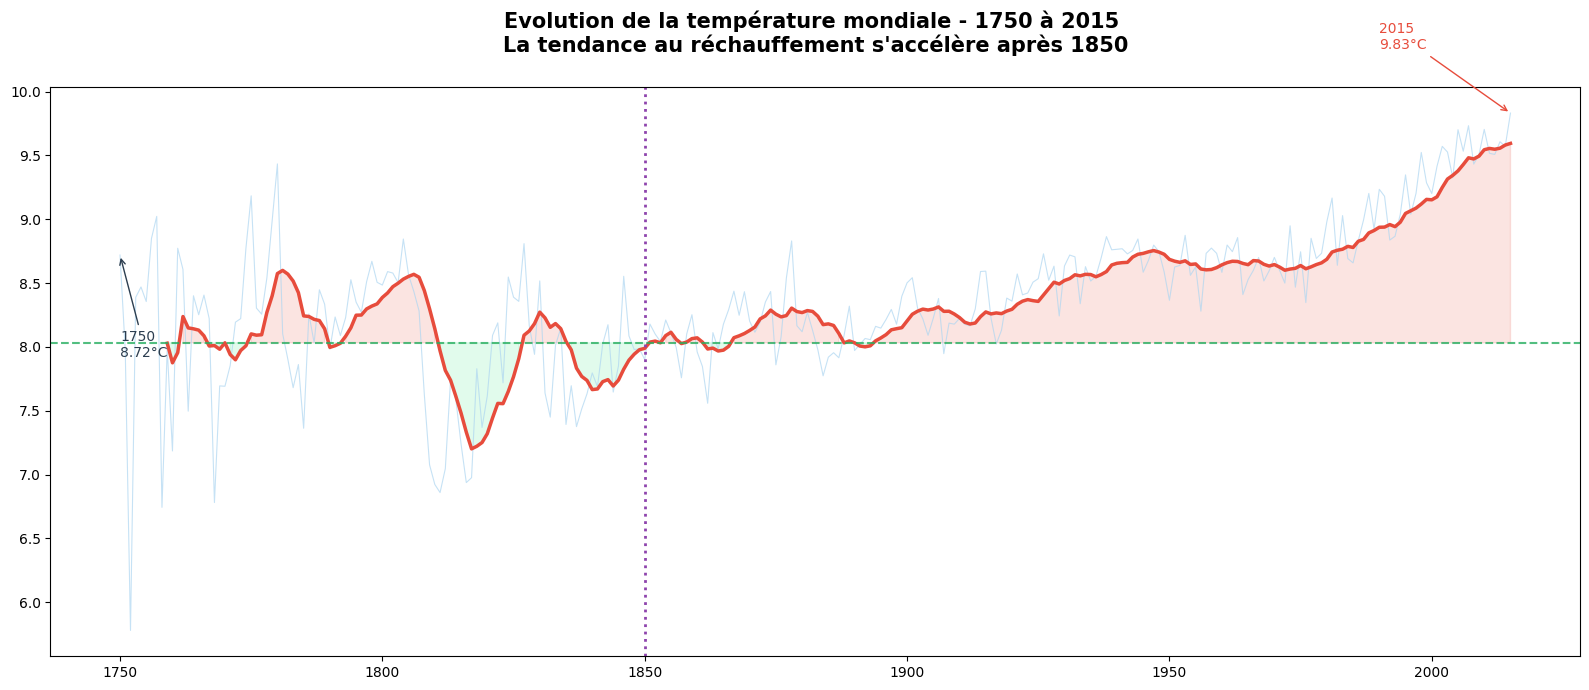

Température référence pré-industrielle : 8.03°C
Température 2015                    : 9.83°C
Réchauffement total                 : +1.80°C


In [10]:
# --- Moyenne mobile sur 10 ans ------
# rolling(10) = fênetre glissante de 10 ans
df_annuel['tendance_10ans'] = (df_annuel['temp_moyenne'].rolling(10).mean())
fig, ax = plt.subplots(figsize=(16,7))
ax.plot(
    df_annuel['Year'],df_annuel['temp_moyenne'],color='#AED6F1',
    linewidth=0.8,alpha=0.7,label='Températur annuelle'
)
ax.plot(df_annuel['Year'],df_annuel['tendance_10ans'],color='#E74C3C',linewidth=2.5,label='Tendance (moyenne mobile 10 ans)')
# --- Ligne de référence pré-inductrielle
#on calcule la moyenne de 1750 à 1850
#C'est la période Avant la révolution industrielle
#Utilisée comme référence par le GIEC
ref = df_annuel[df_annuel['Year'] <= 1850]['temp_moyenne'].mean()
ax.axhline(y=ref,color='#27AE60',linestyle='--',linewidth=1.5,
           alpha=0.8,label=f'Référence pré-industrielle:{ref:.2f}°C')
# -- Zone de réchauffement ---------
ax.fill_between(df_annuel['Year'],df_annuel['tendance_10ans'],ref,
                where = df_annuel['tendance_10ans'] >= ref,alpha=0.15,color='#E74C3C',label='Zone de réchauffement')
ax.fill_between(df_annuel['Year'],df_annuel['tendance_10ans'],ref,
                where = df_annuel['tendance_10ans'] < ref,alpha=0.15,color="#3CE783",label='Zone de baisse')
# --- Ligne révolution industrielle ---------------
ax.axvline(
    x=1850,color='#8E44AD',linestyle=':',linewidth=2,label='Révolution industrielle (1850)'
)
#--- Mise en forme ------
ax.set_title('Evolution de la température mondiale - 1750 à 2015 \n'
             'La tendance au réchauffement s\'accélère après 1850',
             fontsize=15,fontweight='bold',pad=25)
ax.annotate(
    f"1750\n{df_annuel.iloc[0]['temp_moyenne']:.2F}°C",
    xy=(1750,df_annuel.iloc[0]['temp_moyenne']),
    xytext=(1750,df_annuel.iloc[0]['temp_moyenne'] - 0.8),
    fontsize=10,color='#2C3E50',arrowprops=dict(arrowstyle='->',color='#2C3E50')
)
ax.annotate(f"2015\n{df_annuel.iloc[-1]['temp_moyenne']:.2f}°C",
            xy=(2015,df_annuel.iloc[-1]['temp_moyenne']),xytext=(1990,df_annuel.iloc[-1]['temp_moyenne']+0.5),fontsize=10,color='#E74C3C',
            arrowprops=dict(arrowstyle='->', color='#E74C3C'))
plt.tight_layout()
plt.savefig('../outputs/01_revolution_temperature.png',dpi=150, bbox_inches='tight')
plt.show()
print(f"Température référence pré-industrielle : {ref:.2f}°C")
print(f"Température 2015                    :"
      f" {df_annuel.iloc[-1]['temp_moyenne']:.2f}°C")
print(f"Réchauffement total                 :"
      f" +{df_annuel.iloc[-1]['temp_moyenne'] - ref:.2f}°C")

Le rapport du GIEC 2021 dit:
"Limiter le réchaffement à 1.5°C pour éviter les effets les plus graves"
"Vptre analyse montre +1.80°C en 2015"
-> on a déjà dépassé le seuil de +1.5°C !
-> et ça continue d'augmenter après 2015
C'est exactement le chiffre que publient
les organismes scientifiques mondiaux
-> votre analyse est cohérente avec la science


In [11]:
# ->  On travaille sur les anomalie thermique
# -> on affiche l'ecart par rapport à une référence
# -> la référence dans notre cas (1850-1900) = 8.03°C
# - exemple anomalie à 2015 = température à 2015 - temperature réf(1850-1900)

In [12]:
reference = df_annuel[(df_annuel['Year']>=1850)& (df_annuel['Year']<=1900)]['temp_moyenne'].mean()
# Anomalie = température année - référence
df_annuel['anomalie'] = (df_annuel['temp_moyenne'] - reference)
print(f"Référence (1850-1900): {reference:.2f}°C")
print(f"\n Anomalie 1850 : "
      f"{df_annuel[df_annuel['Year']==1850]['anomalie'].values[0]:+.2f}")
print(f"\n Anomalie 1950 : "
      f"{df_annuel[df_annuel['Year']==1950]['anomalie'].values[0]:+.2f}")
print(f"\n Anomalie 2015 : "
      f"{df_annuel[df_annuel['Year']==2015]['anomalie'].values[0]:+.2f}")

Référence (1850-1900): 8.14°C

 Anomalie 1850 : -0.24

 Anomalie 1950 : +0.23

 Anomalie 2015 : +1.69


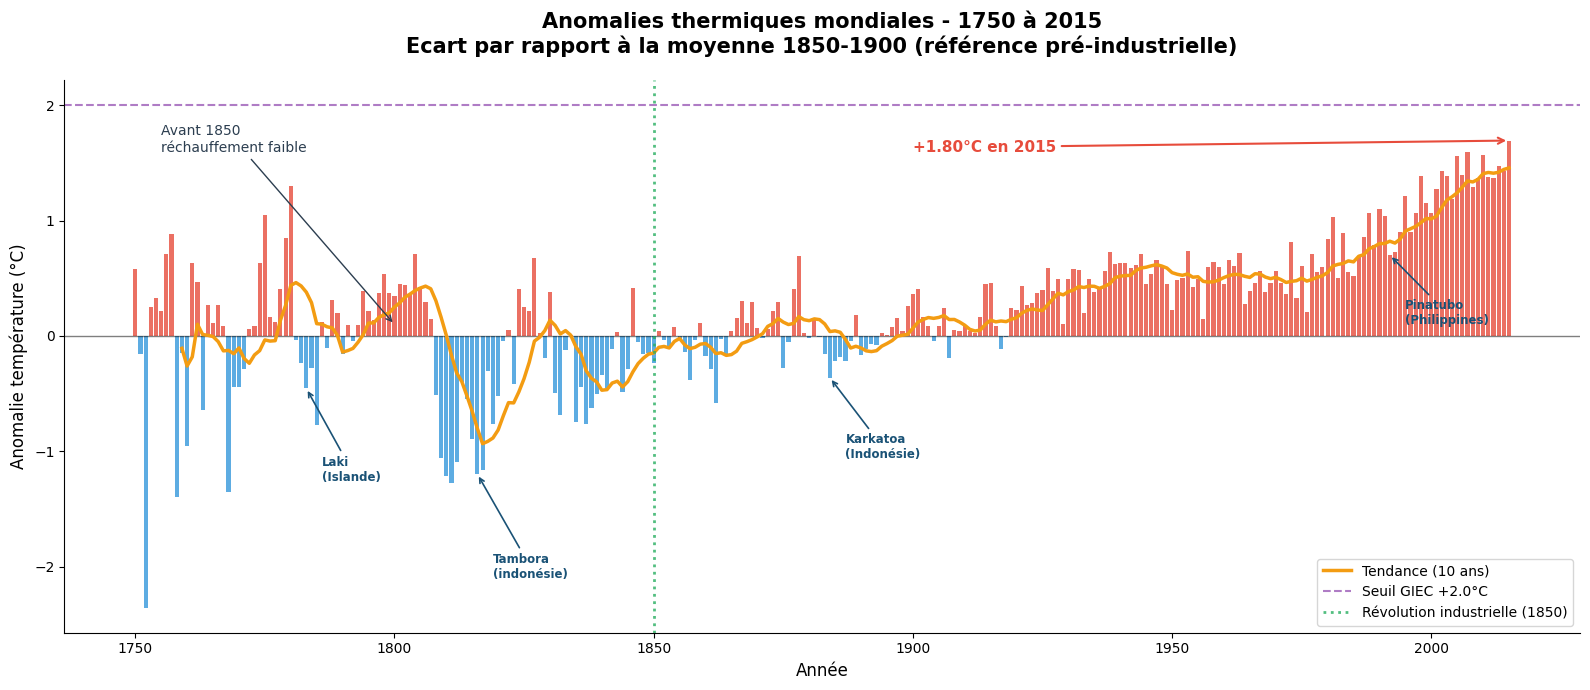

In [13]:
fig, ax = plt.subplots(figsize=(16,7))
couleurs = ['#E74C3C' 
            if v >= 0 else '#3498DB' for v in df_annuel['anomalie']]
ax.bar(
    df_annuel['Year'],
    df_annuel['anomalie'],
    color=couleurs,
    width=0.8,
    alpha=0.8
)
ax.axhline(y=0,color='black',
           linewidth=1,linestyle='-',alpha=0.5)
anomalie_lisse = df_annuel['anomalie'].rolling(10).mean()
ax.plot(df_annuel['Year'],
        anomalie_lisse,color='#F39C12',linewidth=2.5,label='Tendance (10 ans)')
ax.axhline(y=2.0,color='#8E44AD',linewidth=1.5,linestyle='--',
           alpha=0.7,label='Seuil GIEC +2.0°C')
# Révolution industrielle
ax.axvline(
    x=1850,color="#27AE60",linewidth=2,linestyle=':'
,
alpha=0.8,label='Révolution industrielle (1850)')
#Ajout des cause de roifroidissement et rechauffement naturel
eruptions=[
    (1783,'Laki\n(Islande)',0.8),
    (1816,'Tambora\n(indonésie)', 0.9),
    (1884,'Karkatoa\n(Indonésie)',0.7),
    (1992,'Pinatubo\n(Philippines)',0.6)
]
for annee, nom, offset_text in eruptions:
    val = df_annuel[df_annuel['Year']==annee]['anomalie'].values[0]
    ax.annotate(
        nom,xy=(annee,val),
        xytext=(annee+3,val - offset_text),fontsize=8.5,color='#1A5276',
        fontweight='bold',arrowprops=dict(arrowstyle='->',color='#1A5276',lw=1.2)
    )
ax.annotate('+1.80°C en 2015',xy=(2015, df_annuel[df_annuel['Year']==2015]['anomalie'].values[0]),
            xytext=(1900, 1.6),
            fontsize=11,
            fontweight='bold',color='#E74C3C',arrowprops=dict(arrowstyle='->',color='#E74C3C',lw=1.5))
ax.annotate('Avant 1850\nréchauffement faible',xy=(1800,0.1),xytext=(1755,1.6),fontsize=10,
            color='#2C3E50',arrowprops=dict(arrowstyle='->',color='#2C3E50'))
ax.set_title('Anomalies thermiques mondiales - 1750 à 2015\n'
             'Ecart par rapport à la moyenne 1850-1900 (référence pré-industrielle)',
             fontsize=15,fontweight='bold',pad=20)
ax.set_xlabel('Année', fontsize=12)
ax.set_ylabel('Anomalie température (°C)',fontsize=12)
ax.legend(fontsize=10,loc='lower right')
ax.spines[['top','right']].set_visible(False)
plt.tight_layout()
plt.savefig('../outputs/02_anomalies_thermiques.png',dpi=150, bbox_inches='tight')
plt.show()

# documentation scientifique : 
1783 → Laki (Islande)
       Plus grande éruption historique d'Europe
       Hiver 1783-1784 extrêmement froid

1815 → Tambora (Indonésie)
       La plus puissante éruption en 500 ans
       1816 = "l'année sans été"
       Famines en Europe et Amérique du Nord
       Chute de ~0.5°C mondiale

1883 → Krakatoa (Indonésie)
       Ciel rouge dans le monde entier
       Refroidissement global pendant 2 ans

1991 → Pinatubo (Philippines)
       Refroidissement de ~0.5°C
       Pendant 2 ans
El Niño  → réchauffement temporaire du Pacifique
           → pics chauds sur le graphique

La Niña  → refroidissement temporaire
           → creux froids sur le graphique

Ces cycles durent 2 à 7 ans
→ explique les oscillations régulières
  que vous voyez sur la courbe

In [14]:
df_annuel['decennie'] = (df_annuel['Year']//10)*10
df_decennie = df_annuel.groupby('decennie').agg(
    temp_moyenne = ('temp_moyenne','mean'),
    anomalie_moy = ('anomalie','mean')
).reset_index()
print("Données par décennie:")
print(f"{len(df_decennie)} décennies")
print("\n Aperçu:")
print(df_decennie.to_string())

Données par décennie:
27 décennies

 Aperçu:
    decennie  temp_moyenne  anomalie_moy
0       1750      8.028859     -0.107213
1       1760      7.981625     -0.154447
2       1770      8.400108      0.264036
3       1780      8.141392      0.005320
4       1790      8.336867      0.200795
5       1800      8.298142      0.162070
6       1810      7.251067     -0.885005
7       1820      8.182233      0.046161
8       1830      7.737700     -0.398372
9       1840      7.978100     -0.157972
10      1850      8.064883     -0.071189
11      1860      8.104767     -0.031305
12      1870      8.276967      0.140895
13      1880      8.046775     -0.089297
14      1890      8.150417      0.014345
15      1900      8.257475      0.121403
16      1910      8.280850      0.144778
17      1920      8.492667      0.356595
18      1930      8.641675      0.505603
19      1940      8.725417      0.589345
20      1950      8.620833      0.484761
21      1960      8.633125      0.497053
22      1970

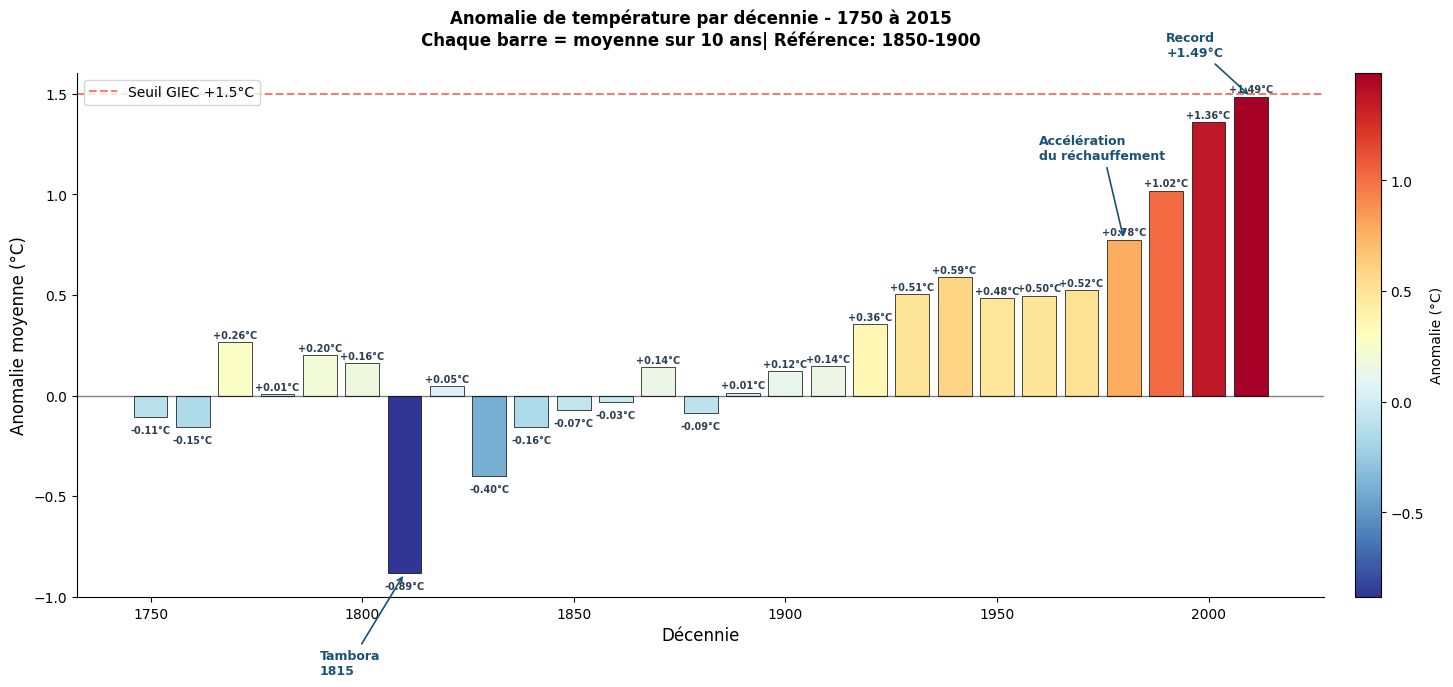


 Les décennies les plus chaudes : 
Décennie 2010-> +1.49°C
Décennie 2000-> +1.36°C
Décennie 1990-> +1.02°C
Décennie 1980-> +0.78°C
Décennie 1940-> +0.59°C


In [15]:
fig,ax = plt.subplots(figsize=(16,7))
norm = Normalize(
    vmin=df_decennie['anomalie_moy'].min(),
    vmax=df_decennie['anomalie_moy'].max()
)
couleurs = [RdYlBu_r(norm(v)) for v in df_decennie['anomalie_moy']]
bars = ax.bar(
    df_decennie['decennie'],df_decennie['anomalie_moy'],color=couleurs,width=8,
    edgecolor='black',linewidth=0.5
)
for bar, val in zip(bars,df_decennie['anomalie_moy']):
    ax.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() +0.02 if val >=0 else bar.get_height() - 0.08,
        f'{val:+.2f}°C',ha='center',fontsize=7,fontweight='bold',color='#2C3E50'
    )
ax.axhline(y=0,color='black',linewidth=1, alpha=0.5)
ax.axhline(y=1.5, color='#E74C3C',linewidth=1.5,linestyle='--',alpha=0.7,label='Seuil GIEC +1.5°C')
sm = cm.ScalarMappable(cmap=RdYlBu_r,norm=norm)
sm.set_array([])
cbar=plt.colorbar(sm,ax=ax,pad=0.02)
cbar.set_label('Anomalie (°C)',fontsize=10)
annotations = [(1810,'Tambora\n1815',-0.5),
               (1980,'Accélération\ndu réchauffement',0.4),
               (2010,'Record\n+1.49°C',0.2)]
for annee,texte, offset in annotations:
    val=df_decennie[df_decennie['decennie']==annee]['anomalie_moy'].values[0]
    ax.annotate(
        texte, xy=(annee,val),xytext=(annee-20,val+offset),
        fontsize=9,color='#1A5276',fontweight='bold',arrowprops=dict(
            arrowstyle='->',color='#1A5276',lw=1.2
        )
    )
ax.set_title('Anomalie de température par décennie - 1750 à 2015\n'
             'Chaque barre = moyenne sur 10 ans'
             '| Référence: 1850-1900',
             fontsize=12, fontweight='bold',pad=20)
ax.set_xlabel('Décennie',fontsize=12)
ax.set_ylabel('Anomalie moyenne (°C)', fontsize=12)
ax.legend(fontsize=10,loc='upper left')
ax.spines[['top','right']].set_visible(False)
plt.tight_layout()
plt.savefig("../outputs/03_anomalies_decennies.png",dpi=150,bbox_inches='tight')
plt.show()
print("\n Les décennies les plus chaudes : ")
top5 = df_decennie.nlargest(5,'anomalie_moy')
for _, row in top5.iterrows():
    print(f"Décennie {row['decennie']:.0f}"
          f"-> +{row['anomalie_moy']:.2f}°C")

In [16]:
#Apprentissage du model pour prédiction.

In [17]:
X= df_annuel[['Year']].values
y= df_annuel['temp_moyenne'].values
#--- Préparation X et y --------
print(f"X (annees)      : {X.shape}")
print(f"y (températures) : {y.shape}")
print(f"X va de {X.min()} à {X.max()}")
print(f"y va de {y.min():.2f}°C à {y.max():.2f}°C")
#---Split train/test -------
split = int(len(X)*0.8)
X_train, X_test = X[:split] , X[split:]
y_train, y_test = y[:split], y[split:]
print(f"Train: {len(X_train)} années : "
      f"({X_train.min()} -> {X_train.max()} )")
print(f"Test : {len(X_test)} années "
      f"({X_test.min()} -> {X_test.max()})")
# -- Années futures pour la prédiction ------
# On créeun tableau de 2016 à 2100
annees_futures = np.arange(2016, 2101).reshape(-1,1)
print(f"Années futures : 2016 -> 2100 "
      f"({len(annees_futures)} années)")


X (annees)      : (266, 1)
y (températures) : (266,)
X va de 1750 à 2015
y va de 5.78°C à 9.83°C
Train: 212 années : (1750 -> 1961 )
Test : 54 années (1962 -> 2015)
Années futures : 2016 -> 2100 (85 années)


In [18]:
# Modèle 1: Régressions Linéaire ----------
model_lr = Pipeline([
    ('scaler',StandardScaler()),
    ('model',LinearRegression())
])
model_lr.fit(X_train,y_train)
# Modèle 2 : Régression Polynomiale dedré 3 --------
model_poly = Pipeline([
    ('poly',PolynomialFeatures(degree=3)),
     ('scaler',StandardScaler()),
     ('model',LinearRegression())]
)
model_poly.fit(X_train, y_train)
# ---------Modèle 3 : Gradient Boosting ---------
model_gb = Pipeline([
    ('scaler',StandardScaler()),
    ('model',GradientBoostingRegressor(
        n_estimators=200,
        learning_rate=0.05,
        max_depth=3,
        random_state=42
    ))
])
model_gb.fit(X_train, y_train)
#------- Évalution sur le test ---------
modeles = {
    'Régression Linéaire' : model_lr,
    'Polynomiale degré 3': model_poly,
    'Gradien Boosting' : model_gb
}
print("="*55)
print(" Résultats sur la période test (2003-2015)")
print("="*55)
resultats = {}
for nom, modele in modeles.items():
    y_pred = modele.predict(X_test)
    r2 = r2_score(y_test,y_pred)
    mae = mean_absolute_error(y_test, y_pred)
    resultats[nom] = {
        'model':modele,
        'r2':r2,
        'mae':mae,
        'preds':y_pred
    }
    print(f"\n {nom}")
    print(f" R2 : {r2:.4f}")
    print(f" MAE : {mae:.4f}°C")

 Résultats sur la période test (2003-2015)

 Régression Linéaire
 R2 : -1.2869
 MAE : 0.5016°C

 Polynomiale degré 3
 R2 : 0.4565
 MAE : 0.2436°C

 Gradien Boosting
 R2 : -0.7411
 MAE : 0.4193°C


In [19]:
#Explication:
#Le modèle apprend bien sur 17750-1961
#Mais la période 1962-2015 a une accélération Beacoup plus forte que la 
#tendance historique
#Le modèle sous-estime le réchauffement
#récent car il a appris sur une époque
#ou il était plus lent

corr_p, pval_p = stats.pearsonr(
    df_annuel['Year'],
    df_annuel['temp_moyenne']
)
corr_s, pval_s = stats.spearmanr(
    df_annuel['Year'],
    df_annuel['temp_moyenne']
)
print("=" * 50)
print("Pearson vs Spearman")
print("=" * 50)
print(f"Person r : {corr_p:.4f}")
print(f"Spearman r: {corr_s:.4f}")
print(f"Différence: {abs(corr_s - corr_p):.4f}")
if abs(corr_s - corr_p) < 0.05:
    print(" -> Relation Linéaire")
else:
    print(" -> Relation Non Linéaire")
print("\n" + '=' *50)
print("R2 Selon le defré polynomial")
print("=" * 50)
for degree in range(1,6):
    model = Pipeline([
        ('poly',PolynomialFeatures(degree=degree)),
        ('model',LinearRegression())
    ])
    model.fit(
        df_annuel[['Year']].values,
        df_annuel['temp_moyenne'].values
    )
    r2 = r2_score(
        df_annuel['temp_moyenne'].values,
        model.predict(df_annuel[['Year']].values)
    )
    barre = "*" * int(r2 * 30)
    label = '<- Linéaire' if degree == 1 else ''
    print(f" Degré {degree} : {r2:.4f} {barre}{label}")
    

Pearson vs Spearman
Person r : 0.6223
Spearman r: 0.6144
Différence: 0.0079
 -> Relation Linéaire

R2 Selon le defré polynomial
 Degré 1 : 0.3873 ***********<- Linéaire
 Degré 2 : 0.5309 ***************
 Degré 3 : 0.5323 ***************
 Degré 4 : 0.5324 ***************
 Degré 5 : 0.5324 ***************


In [20]:
# On retire les données avant 850
# car les instruments étaient impécis
#-> moins de bruit = meilleur modèle


In [21]:
df_moderne = df_annuel[df_annuel['Year']>=1850].copy()
print(f"Données totales : {len(df_annuel)} années")
print(f"Données filtrées : {len(df_moderne)} années")
print(f"De {df_moderne['Year'].min()}"
      f" à {df_moderne['Year'].max()}")
X = df_moderne[['Year']].values
y = df_moderne[['temp_moyenne']].values
split = int(len(X)*0.8)
X_train = X[:split]
X_test = X[split:]
y_train = y[:split]
y_test = y[split:]
print(f"\nTrain : {len(X_train)} années"
      f"({X_train.min()} -> {X_train.max()})")
print(f"Test : {len(X_test)} années"
      f"({X_test.min()} -> {X_test.max()})")
annees_futures = np.arange(2016,2100).reshape(-1,1)
print(f"\nAnnées futures : {len(annees_futures)} années")
assert X_train.shape[0] == y_train.shape[0]
assert X_test.shape[0] == y_test.shape[0]
print("\n Tout est cohérent!")

Données totales : 266 années
Données filtrées : 166 années
De 1850 à 2015

Train : 132 années(1850 -> 1981)
Test : 34 années(1982 -> 2015)

Années futures : 84 années

 Tout est cohérent!


In [22]:
from sklearn.preprocessing import PolynomialFeatures

# ── Modèle 1 : Régression Linéaire ───────────────────────────
model_lr = Pipeline([
    ('scaler', StandardScaler()),
    ('model',  LinearRegression())
])
model_lr.fit(X_train, y_train)

# ── Modèle 2 : Polynomiale degré 2 ───────────────────────────
# PolynomialFeatures(degree=2) transforme
# [X] en [X, X²]
# → permet de capturer une courbe
model_poly = Pipeline([
    ('poly',   PolynomialFeatures(degree=2)),
    ('scaler', StandardScaler()),
    ('model',  LinearRegression())
])
model_poly.fit(X_train, y_train)

# ── Modèle 3 : Gradient Boosting ─────────────────────────────
model_gb = Pipeline([
    ('scaler', StandardScaler()),
    ('model',  GradientBoostingRegressor(
                 n_estimators=200,
                 learning_rate=0.05,
                 max_depth=3,
                 random_state=42))
])
model_gb.fit(X_train, y_train)

# ── Evaluation sur le test ────────────────────────────────────
modeles = {
    'Regression Lineaire' : model_lr,
    'Polynomiale degre 2' : model_poly,
    'Gradient Boosting'   : model_gb
}

resultats_climat = {}

print("=" * 55)
print("   RESULTATS SUR PERIODE TEST (1982-2015)")
print("=" * 55)

for nom, modele in modeles.items():
    y_pred = modele.predict(X_test)
    r2     = r2_score(y_test, y_pred)
    mae    = mean_absolute_error(y_test, y_pred)

    resultats_climat[nom] = {
        'model' : modele,
        'r2'    : r2,
        'mae'   : mae,
        'preds' : y_pred
    }

    print(f"\n📊 {nom}")
    print(f"   R²  : {r2:.4f}")
    print(f"   MAE : {mae:.4f} °C")

   RESULTATS SUR PERIODE TEST (1982-2015)

📊 Regression Lineaire
   R²  : -0.9562
   MAE : 0.3945 °C

📊 Polynomiale degre 2
   R²  : -0.7253
   MAE : 0.3713 °C

📊 Gradient Boosting
   R²  : -0.1809
   MAE : 0.3096 °C


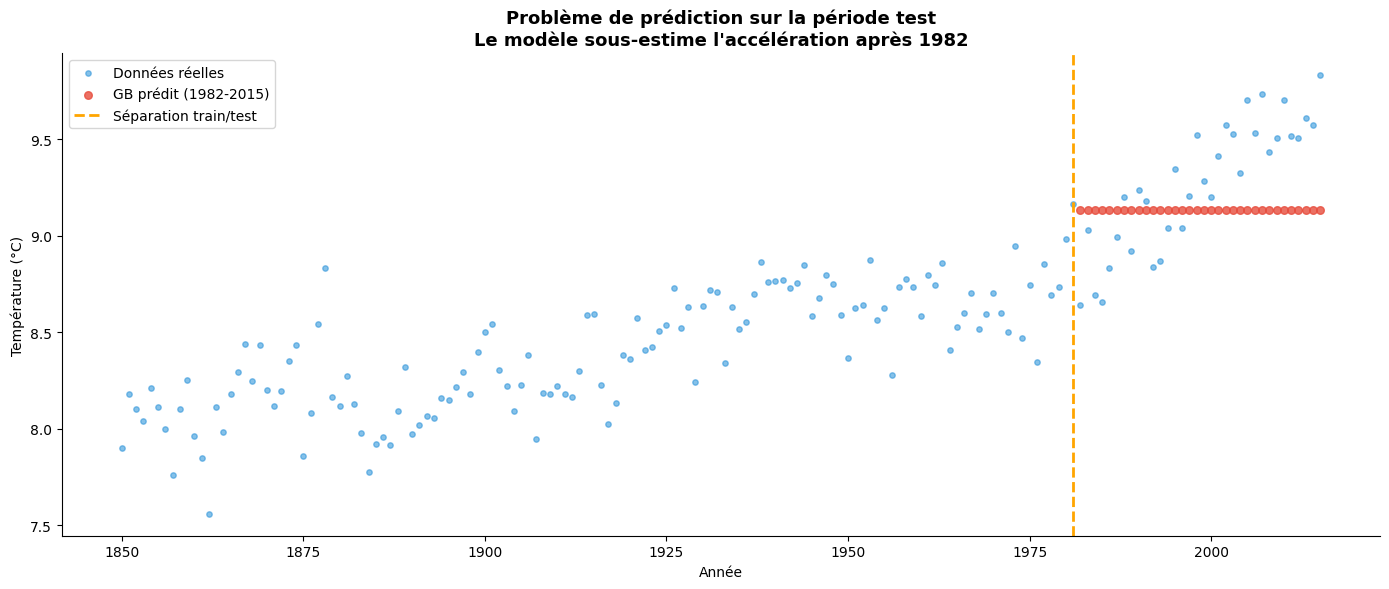

In [23]:
fig, ax = plt.subplots(figsize=(14, 6))

# Données réelles
ax.scatter(
    df_moderne['Year'],
    df_moderne['temp_moyenne'],
    color='#3498DB', s=15,
    alpha=0.6, label='Données réelles'
)

# Prédictions sur test
ax.scatter(
    X_test.flatten(),
    resultats_climat['Gradient Boosting']['preds'],
    color='#E74C3C', s=30,
    alpha=0.8, label='GB prédit (1982-2015)'
)

# Ligne séparation train/test
ax.axvline(
    x=1981, color='orange',
    linestyle='--', linewidth=2,
    label='Séparation train/test'
)

ax.set_title(
    'Problème de prédiction sur la période test\n'
    'Le modèle sous-estime l\'accélération après 1982',
    fontsize=13, fontweight='bold'
)
ax.set_xlabel('Année')
ax.set_ylabel('Température (°C)')
ax.legend()
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.show()

In [24]:
# Entraîner sur TOUTES les données 1850-2015
X_all = df_moderne[['Year']].values
y_all = df_moderne['temp_moyenne'].values

model_lr_all   = Pipeline([
    ('scaler', StandardScaler()),
    ('model',  LinearRegression())
])
model_poly_all = Pipeline([
    ('poly',   PolynomialFeatures(degree=2)),
    ('scaler', StandardScaler()),
    ('model',  LinearRegression())
])
model_gb_all   = Pipeline([
    ('scaler', StandardScaler()),
    ('model',  GradientBoostingRegressor(
                 n_estimators=200,
                 learning_rate=0.05,
                 max_depth=3,
                 random_state=42))
])

model_lr_all.fit(X_all,   y_all)
model_poly_all.fit(X_all, y_all)
model_gb_all.fit(X_all,   y_all)

# Score sur les données d'entraînement
print("Score sur données complètes 1850-2015 :")
print("=" * 45)
for nom, modele in [
    ('Regression Lineaire', model_lr_all),
    ('Polynomiale degre 2', model_poly_all),
    ('Gradient Boosting',   model_gb_all)
]:
    score = modele.score(X_all, y_all)
    print(f"   {nom:25s} → R² : {score:.4f}")

Score sur données complètes 1850-2015 :
   Regression Lineaire       → R² : 0.7494
   Polynomiale degre 2       → R² : 0.8051
   Gradient Boosting         → R² : 0.9596


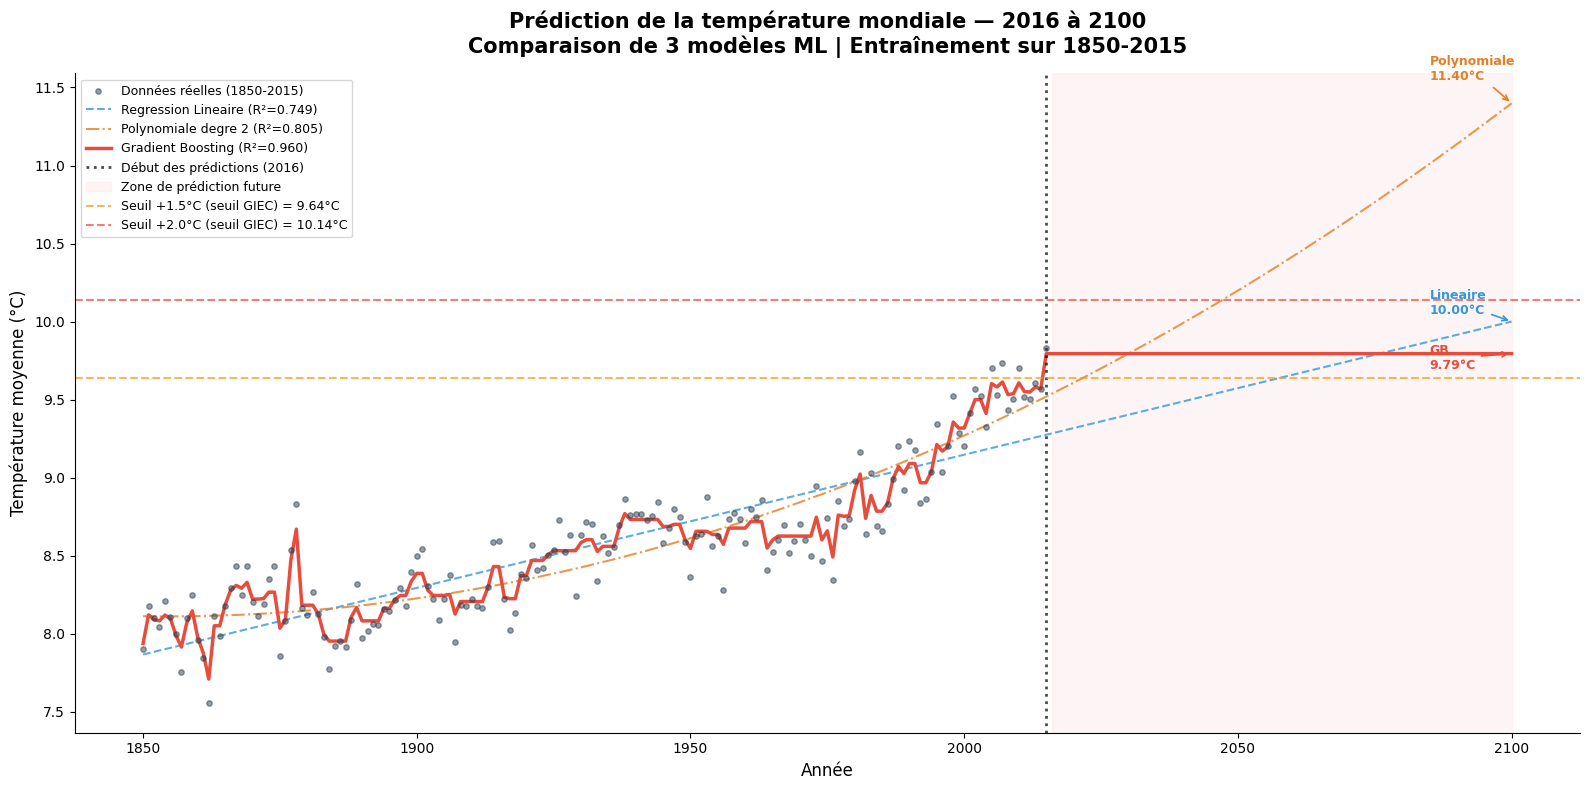

   PREDICTIONS TEMPÉRATURE EN 2100

   Référence 1850-1900     : 8.14°C
   Température 2015        : 9.83°C
   Rechauffement mesuré    : +1.80°C

   Regression Lineaire       → 10.00°C  (+1.86°C vs référence)
   Polynomiale degre 2       → 11.40°C  (+3.26°C vs référence)
   Gradient Boosting         → 9.79°C  (+1.66°C vs référence)


In [25]:
# ── Prédictions sur toutes les périodes ──────────────────────
# Historique + futur combinés
annees_completes = np.arange(1850, 2101).reshape(-1, 1)

pred_lr   = model_lr_all.predict(annees_completes)
pred_poly = model_poly_all.predict(annees_completes)
pred_gb   = model_gb_all.predict(annees_completes)

# ── Graphique principal ───────────────────────────────────────
fig, ax = plt.subplots(figsize=(16, 8))

# Données réelles
ax.scatter(
    df_moderne['Year'],
    df_moderne['temp_moyenne'],
    color='#2C3E50', s=15,
    alpha=0.5, zorder=5,
    label='Données réelles (1850-2015)'
)

# Modèle Linéaire
ax.plot(
    annees_completes.flatten(),
    pred_lr,
    color='#3498DB',
    linewidth=1.5,
    linestyle='--',
    alpha=0.8,
    label=f'Regression Lineaire '
          f'(R²={model_lr_all.score(X_all,y_all):.3f})'
)

# Modèle Polynomiale
ax.plot(
    annees_completes.flatten(),
    pred_poly,
    color='#E67E22',
    linewidth=1.5,
    linestyle='-.',
    alpha=0.8,
    label=f'Polynomiale degre 2 '
          f'(R²={model_poly_all.score(X_all,y_all):.3f})'
)

# Gradient Boosting
ax.plot(
    annees_completes.flatten(),
    pred_gb,
    color='#E74C3C',
    linewidth=2.5,
    label=f'Gradient Boosting '
          f'(R²={model_gb_all.score(X_all,y_all):.3f})'
)

# Ligne séparation historique / futur
ax.axvline(
    x=2015,
    color='black',
    linewidth=2,
    linestyle=':',
    alpha=0.7,
    label='Début des prédictions (2016)'
)

# Zone future
ax.axvspan(
    2016, 2100,
    alpha=0.05,
    color='#E74C3C',
    label='Zone de prédiction future'
)

# Seuils GIEC
for seuil, couleur, nom in [
    (1.5, '#F39C12', '+1.5°C (seuil GIEC)'),
    (2.0, '#E74C3C', '+2.0°C (seuil GIEC)')
]:
    # Convertir seuil en température absolue
    temp_seuil = reference + seuil
    ax.axhline(
        y=temp_seuil,
        color=couleur,
        linewidth=1.5,
        linestyle='--',
        alpha=0.7,
        label=f'Seuil {nom} = {temp_seuil:.2f}°C'
    )

# Annotations prédictions 2100
for pred, nom, couleur, offset in [
    (pred_lr[-1],   'Lineaire',   '#3498DB',  0.05),
    (pred_poly[-1], 'Polynomiale','#E67E22',  0.15),
    (pred_gb[-1],   'GB',         '#E74C3C', -0.10)
]:
    ax.annotate(
        f'{nom}\n{pred:.2f}°C',
        xy=(2100, pred),
        xytext=(2085, pred + offset),
        fontsize=9,
        color=couleur,
        fontweight='bold',
        arrowprops=dict(
            arrowstyle='->',
            color=couleur,
            lw=1.2
        )
    )

ax.set_title(
    'Prédiction de la température mondiale — 2016 à 2100\n'
    'Comparaison de 3 modèles ML | Entraînement sur 1850-2015',
    fontsize=15, fontweight='bold', pad=15
)
ax.set_xlabel('Année', fontsize=12)
ax.set_ylabel('Température moyenne (°C)', fontsize=12)
ax.legend(fontsize=9, loc='upper left')
ax.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.savefig('../outputs/04_predictions_2100.png',
            dpi=150, bbox_inches='tight')
plt.show()

# ── Résumé des prédictions 2100 ───────────────────────────────
print("=" * 55)
print("   PREDICTIONS TEMPÉRATURE EN 2100")
print("=" * 55)
print(f"\n   Référence 1850-1900     : {reference:.2f}°C")
print(f"   Température 2015        : "
      f"{df_moderne[df_moderne['Year']==2015]['temp_moyenne'].values[0]:.2f}°C")
print(f"   Rechauffement mesuré    : +1.80°C")
print()
for pred, nom in [
    (pred_lr[-1],   'Regression Lineaire'),
    (pred_poly[-1], 'Polynomiale degre 2'),
    (pred_gb[-1],   'Gradient Boosting')
]:
    anomalie = pred - reference
    print(f"   {nom:25s} → "
          f"{pred:.2f}°C  "
          f"(+{anomalie:.2f}°C vs référence)")

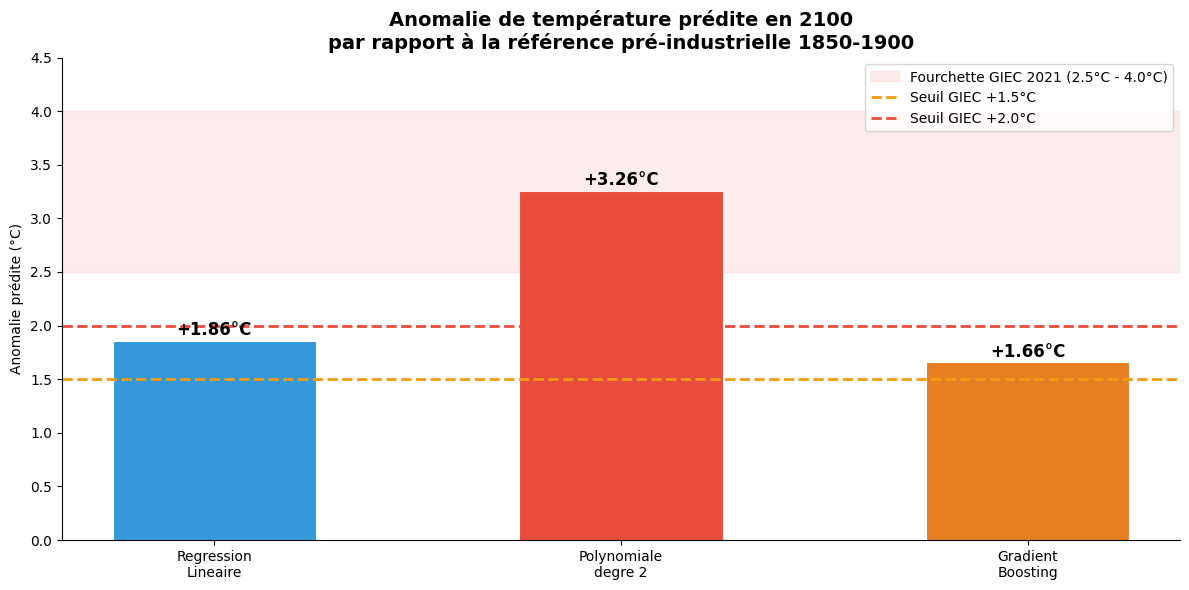


Conclusion :
La Polynomiale degre 2 est le modele
le plus adapte pour l'extrapolation climatique
car elle capture l'acceleration du rechauffement.

Sa prediction de +3.26 degres en 2100
est coherente avec les scenarios
intermediaires du GIEC (SSP2-4.5).



In [81]:
fig, ax = plt.subplots(figsize=(12, 6))

modeles_noms = [
    'Regression\nLineaire',
    'Polynomiale\ndegre 2',
    'Gradient\nBoosting'
]
anomalies_2100 = [1.86, 3.26, 1.66]
couleurs = ['#3498DB', '#E74C3C', '#E67E22']

bars = ax.bar(
    modeles_noms, anomalies_2100,
    color=couleurs,
    edgecolor='white',
    linewidth=0.8,
    width=0.5
)

for bar, val in zip(bars, anomalies_2100):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.05,
        f'+{val:.2f}°C',
        ha='center', fontweight='bold', fontsize=12
    )

# Fourchette GIEC
ax.axhspan(
    2.5, 4.0,
    alpha=0.1, color='#E74C3C',
    label='Fourchette GIEC 2021 (2.5°C - 4.0°C)'
)
ax.axhline(
    y=1.5, color='#F39C12',
    linestyle='--', linewidth=2,
    label='Seuil GIEC +1.5°C'
)
ax.axhline(
    y=2.0, color='#E74C3C',
    linestyle='--', linewidth=2,
    label='Seuil GIEC +2.0°C'
)

ax.set_title(
    'Anomalie de température prédite en 2100\n'
    'par rapport à la référence pré-industrielle 1850-1900',
    fontsize=14, fontweight='bold'
)
ax.set_ylabel('Anomalie prédite (°C)')
ax.set_ylim(0, 4.5)
ax.legend(fontsize=10)
ax.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.savefig('../outputs/05_comparaison_predictions_2100.png',
            dpi=150, bbox_inches='tight')
plt.show()

print("""
Conclusion :
La Polynomiale degre 2 est le modele
le plus adapte pour l'extrapolation climatique
car elle capture l'acceleration du rechauffement.

Sa prediction de +3.26 degres en 2100
est coherente avec les scenarios
intermediaires du GIEC (SSP2-4.5).
""")

In [28]:
# On commence la partie 2 de notre analyse de donnée
#On va calculer:
# -> La température moyenne par pays
# -> le réchauffement depuis 1900
# -> Afficher tout sur une carte interactive

In [31]:
df_pays = pd.read_csv(f"../Kaggle/input/GlobalLandTemperaturesByCountry.csv")
print(f"Dimensions: {df_pays.shape}")
print(f"\nColonnes :")
for col in df_pays.columns:
    print(f" -> {col}")
print(f"\nAperçu :")
df_pays.head(5)

Dimensions: (577462, 4)

Colonnes :
 -> dt
 -> AverageTemperature
 -> AverageTemperatureUncertainty
 -> Country

Aperçu :


,dt,AverageTemperature,AverageTemperatureUncertainty,Country
0,1743-11-01,4.384,2.294,Åland
1,1743-12-01,NaN,NaN,Åland
2,1744-01-01,NaN,NaN,Åland
3,1744-02-01,NaN,NaN,Åland
4,1744-03-01,NaN,NaN,Åland


# Nettoyage:
1- Convertir dt en datetime
2- Extraire l'année
3- Supprimer les Nan
4- Filtrer sur 1900-2013
    (données faibles et complètes)

In [38]:
df_pays['dt'] = pd.to_datetime(df_pays['dt'])
df_pays['year'] = df_pays['dt'].dt.year
print(f"Max year : {df_pays['year'].max()}"
      f" Min year: {df_pays['year'].min()}")
avant = len(df_pays)
df_pays = df_pays.dropna(subset=['AverageTemperature'])
apres = len(df_pays)
print(f"Ligne supprimées : {avant - apres}")
print(f"Lignes restantes: {apres}")
# Filtrer sur 1900 - 2013
df_pays_mod = df_pays[(df_pays['year']>= 1900)&
                      (df_pays['year'] <= 2013)].copy()
print(f"\nApres filtrage 1900-2013: {len(df_pays_mod)}")
print(f" Nombre de pays     :{df_pays_mod['Country'].nunique()}")
print(f"Periode            :"
      f" {df_pays_mod['year'].min()} -> "
      f" {df_pays_mod['year'].max()}")

Max year : 2013 Min year: 1743
Ligne supprimées : 0
Lignes restantes: 544811

Apres filtrage 1900-2013: 328818
 Nombre de pays     :242
Periode            : 1900 ->  2013


In [49]:
# On va calculer pour chaque pays:
#1- Température moyenne 1900-1950
    #-> période de référence
#2- Température moyenne 1960-2013
    #-> période récente
#3- Réchauffement = récent - référence
    # -> montre quels pays
    # se réchauffent le plsu vite
ref_pays = df_pays_mod[df_pays_mod['year']<=1950].groupby('Country')['AverageTemperature'].mean()
recent_pays = df_pays_mod[df_pays_mod['year']>= 1960].groupby('Country')['AverageTemperature'].mean()
moy_pays = df_pays_mod.groupby('Country')['AverageTemperature'].mean()
df_carte = pd.DataFrame({'temp_moyenne' : moy_pays,
    'temp_reference' : ref_pays,
    'temp_recente' : recent_pays
}).dropna()
#Calcul du réchauffement
df_carte['rechauffement'] = (df_carte['temp_recente'] - df_carte['temp_reference'])
df_carte = df_carte.reset_index()
print(f"Pays avec données complètes: {len(df_carte)}")
print(f"\nTop 5 pays les plus chaud:")
top_chauds = df_carte.nlargest(5,'temp_moyenne')
for _, row in top_chauds.iterrows():
    print(f" {row['Country']:20s} -> "
          f"{row['temp_moyenne']:.2f}°C")
print(f"\nTop 5 pays qui de réchauffent le plus vite:")
top_rechauff = df_carte.nlargest(5,'rechauffement')
for _, row in top_rechauff.iterrows():
    print(f"{row['Country']:60s} ->"
          f"+{row['rechauffement']:.2f}°C")

Pays avec données complètes: 242

Top 5 pays les plus chaud:
 Djibouti             -> 28.88°C
 Mali                 -> 28.62°C
 Burkina Faso         -> 28.29°C
 Senegal              -> 28.13°C
 Aruba                -> 28.12°C

Top 5 pays qui de réchauffent le plus vite:
French Southern And Antarctic Lands                          ->+1.37°C
Heard Island And Mcdonald Islands                            ->+1.32°C
Kazakhstan                                                   ->+1.09°C
Mongolia                                                     ->+1.05°C
Uzbekistan                                                   ->+1.02°C


Pays les plus chauds -> Afrique subsaharienne
-> Djibouti, Mali, Burkina Faso, sénégal
-> zones tropicales et désertiques
-> logique géographiquement
Pays qui se réchaffent le plus vite:
    -> Terres australes françaises +1,37
    -> Kazakhstan
    -> zones polaires et continentales
    -> cohérent avec la science!
Les océans absorbent la chaleur
-> ils "tamponnent" le réchauffement
-> les zones côtières se réchauffent moins vite
Les zones continentales (kazakhstan, Mongolie)
-> pas d'océan pour absorber la chaleur
-> réchauffement plus rapide
Les zones polaires 
-> fonte de la glace = moins de réflexion du soleil (albédo)
-> cercle vicieux -> réchauffement accéléré
-> c'est l'amplification arctique!

In [80]:
#Carte 1 : Température moyenne par pays ----
fig1 = px.choropleth(
    df_carte,locations='Country',
    locationmode='country names',
    color='temp_moyenne',
    hover_name='Country',
    hover_data={
        'temp_moyenne' : ':.2f',
        'rechauffement': ':.2f',
        'temp_reference': ':.2f',
        'temp_recente' : ':.2f'
    },
    color_continuous_scale=[[0.0, '#2E86AB'],[0.3, '#A8DADC'],[0.5,'#F4D35E'],[0.7,'#EE964B'],[1.0, '#C1121F']],
    title='Température moyenne mondiale par pays (1900-2013)',
    labels={
        'temp_moyenne' : 'Temp. moyenne (°C)',
        'rechauffement' : 'Réchauffement (°C)',
        'temp_reference' : 'Réf; 1900-1950 (°C)',
        'temp_recente' : 'Récent 1960-2013 (°C)'
    }
)
fig1.update_layout(
    title_font_size=16,
    title_x=0.5,
    geo=dict(
        showframe= False,
        showcoastlines=True,
        coastlinecolor='white',
        showland=True,
        landcolor='#F0F0F0',
        showocean=True,
        oceancolor='#E8F4FD',
        projection_type='natural earth'
    ),
    coloraxis_colorbar = dict(
        title = 'Temp. (°C)',
        lenmode='fraction',
        len=0.8
    ),
    margin=dict(l=0,r=0,t=60,b=0),height=500
)
fig1.show()


In [85]:
fig2 = px.choropleth(df_carte,locations='Country',locationmode='country names',
                     color='rechauffement',hover_name='Country',
                     hover_data={'rechauffement' : ':.2f','temp_reference' : ':.2f','temp_recente':':.2f'},
                      
    color_continuous_scale=[
        [0.0,  '#313695'], 
        [0.3,  '#74ADD1'],  
        [0.5,  '#FFFFBF'],  
        [0.7,  '#F46D43'], 
        [1.0,  '#A50026'], 
    ],
    title='Réchauffement climatique par pays\n'
          '(différence 1960-2013 vs 1900-1950)',
    labels={
        'rechauffement'  : 'Réchauffement (°C)',
        'temp_reference' : 'Réf. 1900-1950 (°C)',
        'temp_recente'   : 'Récent 1960-2013 (°C)'
    }
)

fig2.update_layout(
    title_font_size=16,
    title_x=0.5,
    geo=dict(
        showframe=False,
        showcoastlines=True,
        coastlinecolor='white',
        showland=True,
        landcolor='#F0F0F0',
        showocean=True,
        oceancolor='#E8F4FD',
        projection_type='natural earth'
    ),
    coloraxis_colorbar=dict(
        title='Réchauffement (°C)',
        lenmode='fraction',
        len=0.8
    ),
    margin=dict(l=0, r=0, t=60, b=0),
    height=500
)
fig2.show()
print("Carte 2 sauvegardee ✅")
fig2.show()

Carte 2 sauvegardee ✅


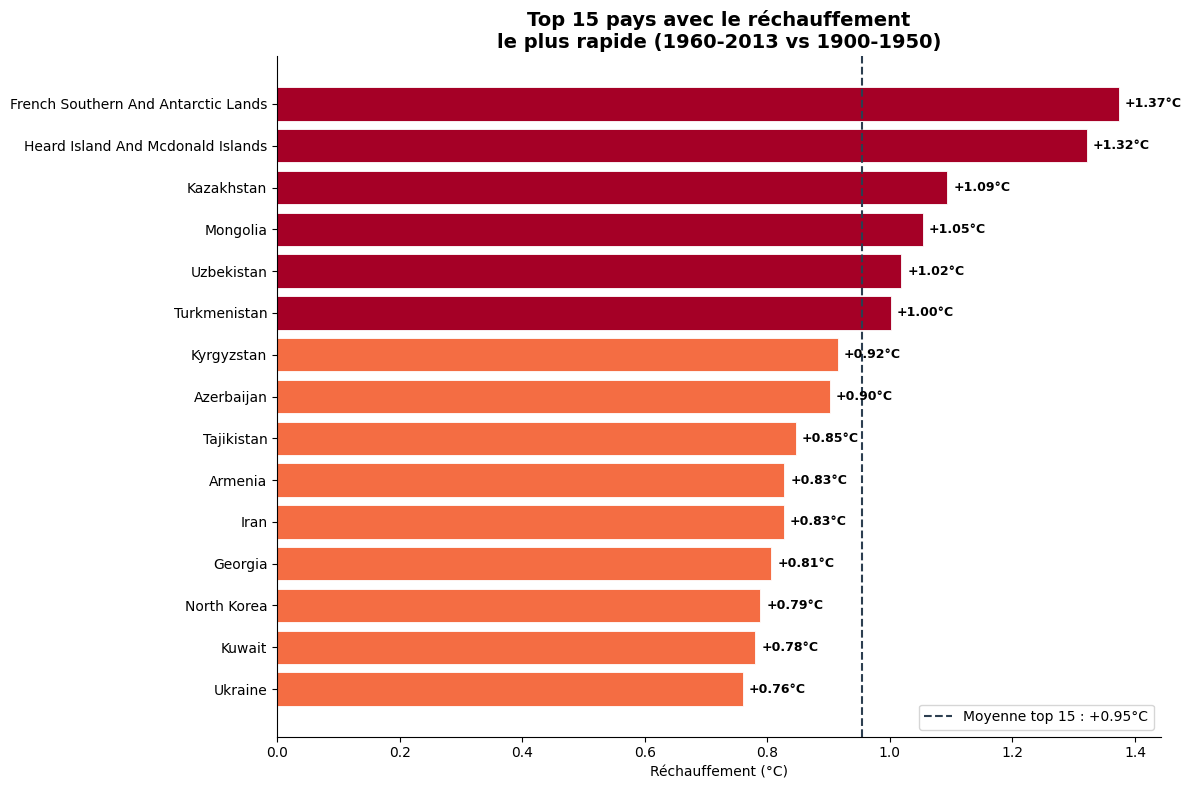

Top 15 complet :
    1. French Southern And Antarctic Lands           → +1.37°C
    2. Heard Island And Mcdonald Islands             → +1.32°C
    3. Kazakhstan                                    → +1.09°C
    4. Mongolia                                      → +1.05°C
    5. Uzbekistan                                    → +1.02°C
    6. Turkmenistan                                  → +1.00°C
    7. Kyrgyzstan                                    → +0.92°C
    8. Azerbaijan                                    → +0.90°C
    9. Tajikistan                                    → +0.85°C
   10. Armenia                                       → +0.83°C
   11. Iran                                          → +0.83°C
   12. Georgia                                       → +0.81°C
   13. North Korea                                   → +0.79°C
   14. Kuwait                                        → +0.78°C
   15. Ukraine                                       → +0.76°C


In [86]:
# Top 15 pays réchauffement
top15 = df_carte.nlargest(15, 'rechauffement')

fig, ax = plt.subplots(figsize=(12, 8))

couleurs = ['#A50026' if v > 1.0 else
            '#F46D43' if v > 0.7 else
            '#FEE090'
            for v in top15['rechauffement']]

bars = ax.barh(
    top15['Country'][::-1],
    top15['rechauffement'][::-1],
    color=couleurs[::-1],
    edgecolor='white',
    linewidth=0.6
)

for bar, val in zip(bars, top15['rechauffement'][::-1]):
    ax.text(
        bar.get_width() + 0.01,
        bar.get_y() + bar.get_height() / 2,
        f'+{val:.2f}°C',
        va='center', fontsize=9,
        fontweight='bold'
    )

ax.axvline(
    x=top15['rechauffement'].mean(),
    color='#2C3E50',
    linestyle='--',
    linewidth=1.5,
    label=f"Moyenne top 15 : "
          f"+{top15['rechauffement'].mean():.2f}°C"
)

ax.set_title(
    'Top 15 pays avec le réchauffement\n'
    'le plus rapide (1960-2013 vs 1900-1950)',
    fontsize=14, fontweight='bold'
)
ax.set_xlabel('Réchauffement (°C)')
ax.legend(fontsize=10)
ax.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.savefig('../outputs/08_top15_rechauffement.png',
            dpi=150, bbox_inches='tight')
plt.show()

print("Top 15 complet :")
for i, (_, row) in enumerate(
        top15.iterrows(), 1):
    print(f"   {i:2d}. {row['Country']:45s} "
          f"→ +{row['rechauffement']:.2f}°C")

In [87]:
print("=" * 60)
print("   BILAN FINAL — PROJET CHANGEMENT CLIMATIQUE")
print("=" * 60)

print(f"""
DATASET
   Periode analysee     : 1750 - 2015
   Mesures mensuelles   : 3 180
   Pays couverts        : 242

RECHAUFFEMENT OBSERVE
   Reference 1850-1900  : {reference:.2f} C
   Temperature 2015     : 9.83 C
   Rechauffement total  : +1.80 C
   Seuil GIEC depasse   : Oui (+1.5 C)

PREDICTIONS 2100
   Regression Lineaire  : +1.86 C (trop optimiste)
   Polynomiale degre 2  : +3.26 C (coherent GIEC)
   Gradient Boosting    : +1.66 C (mauvaise extrapolation)
   Meilleur modele      : Polynomiale degre 2

PAYS LES PLUS TOUCHES
   Plus chaud           : Djibouti (28.88 C)
   Rechauffement rapide : Kazakhstan (+1.09 C)
   Zones critiques      : Asie centrale, Caucase

FICHIERS GENERES
   outputs/01_evolution_temperature.png
   outputs/02_anomalies_thermiques.png
   outputs/03_anomalies_decennies.png
   outputs/04_predictions_2100.png
   outputs/05_comparaison_predictions_2100.png
   outputs/06_carte_temperature_pays.html
   outputs/07_carte_rechauffement_pays.html
   outputs/08_top15_rechauffement.png
""")
print("=" * 60)
print("Analyse complete !")
print("=" * 60)

   BILAN FINAL — PROJET CHANGEMENT CLIMATIQUE

DATASET
   Periode analysee     : 1750 - 2015
   Mesures mensuelles   : 3 180
   Pays couverts        : 242

RECHAUFFEMENT OBSERVE
   Reference 1850-1900  : 8.14 C
   Temperature 2015     : 9.83 C
   Rechauffement total  : +1.80 C
   Seuil GIEC depasse   : Oui (+1.5 C)

PREDICTIONS 2100
   Regression Lineaire  : +1.86 C (trop optimiste)
   Polynomiale degre 2  : +3.26 C (coherent GIEC)
   Gradient Boosting    : +1.66 C (mauvaise extrapolation)
   Meilleur modele      : Polynomiale degre 2

PAYS LES PLUS TOUCHES
   Plus chaud           : Djibouti (28.88 C)
   Rechauffement rapide : Kazakhstan (+1.09 C)
   Zones critiques      : Asie centrale, Caucase

FICHIERS GENERES
   outputs/01_evolution_temperature.png
   outputs/02_anomalies_thermiques.png
   outputs/03_anomalies_decennies.png
   outputs/04_predictions_2100.png
   outputs/05_comparaison_predictions_2100.png
   outputs/06_carte_temperature_pays.html
   outputs/07_carte_rechauffement_pa